# Missing Indicators in Machine Learning

A **missing indicator** is a binary feature (0 or 1) added to a dataset during preprocessing to explicitly flag whether an original value was missing in a specific column.

> While standard methods like mean or median imputation fill in the empty spaces so a model can run, they erase the information that the data was ever missing. A missing indicator ensures your model can learn from that absence, as "missingness" itself often holds predictive value.

### Real-World Example
- A missing salary value in a banking dataset might indicate a high-income individual refusing to disclose it
- A missing medical test could mean a doctor deemed it unnecessary

---

## How It Works

Imagine a simple column for Age with a missing entry:

| Original Age | Imputed Age (Median) | Age_Is_Missing (Indicator) |
|--------------|---------------------|---------------------------|
| 25           | 25                  | 0                         |
| NaN          | 30                  | 1                         |
| 35           | 35                  | 0                         |


---

## Pros & Cons

### ✅ Pros
- Captures hidden patterns or behavior when data is **not missing at random**
- Simple to implement and highly interpretable for models

### ❌ Cons
- Doubles the number of columns if applied to every feature, which can cause **overfitting** in high-dimensional datasets
- Can introduce **bias** in certain clinical or non-randomized health studies if not treated carefully

In [113]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer, MissingIndicator

In [114]:
df = pd.read_csv('train.csv', usecols = ['Age', 'Fare', 'Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [115]:
df.isnull().mean()

Survived    0.000000
Age         0.198653
Fare        0.000000
dtype: float64

In [116]:
X = df.drop(columns = ['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [117]:
X_train.isnull().mean()

Age     0.196629
Fare    0.000000
dtype: float64

In [118]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,572.0,29.498846,14.500059,0.42,21.000,28.0000,38.0,80.0000
Fare,712.0,32.586276,51.969529,0.00,7.925,14.4542,30.5,512.3292


In [119]:
# Impute missing value without missing indicator
simple_imputer = SimpleImputer()
simple_imputer.set_output(transform = 'pandas')

SimpleImputer()

In [120]:
X_train_transformed = simple_imputer.fit_transform(X_train)
X_test_transformed = simple_imputer.transform(X_test)

In [121]:
simple_imputer.statistics_

array([29.49884615, 32.58627612])

In [122]:
X_train_transformed.isnull().mean()

Age     0.0
Fare    0.0
dtype: float64

In [123]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

clf = LogisticRegression()

clf.fit(X_train_transformed, y_train)
y_predict = clf.predict(X_test_transformed)

print(f'Accuracy Score: {accuracy_score(y_test, y_predict)}')

Accuracy Score: 0.6480446927374302


In [124]:
# Impute missing values with missing indicator
missing_indicator = MissingIndicator()
missing_indicator.set_output(transform = 'pandas')

X_train_missing = missing_indicator.fit_transform(X_train)
X_test_missing = missing_indicator.transform(X_test)

In [125]:
X_train['Age_NA'] = X_train_missing
X_test['Age_NA'] = X_test_missing

In [126]:
X_train

,Age,Fare,Age_NA
331,45.5,28.5000,False
733,23.0,13.0000,False
382,32.0,7.9250,False
704,26.0,7.8542,False
813,6.0,31.2750,False
...,...,...,...
106,21.0,7.6500,False
270,NaN,31.0000,True
860,41.0,14.1083,False
435,14.0,120.0000,False


In [127]:
simple_imputer = SimpleImputer()
simple_imputer.set_output(transform = 'pandas')


X_train_imputed = simple_imputer.fit_transform(X_train)
X_test_imputed = simple_imputer.transform(X_test)

In [128]:
clf = LogisticRegression()

clf.fit(X_train_imputed, y_train)
y_predict = clf.predict(X_test_imputed)

print(f'Accuracy Score: {accuracy_score(y_test, y_predict)}')

Accuracy Score: 0.6368715083798883


In [129]:
si = SimpleImputer(strategy='mean', add_indicator=True)
si.set_output(transform='pandas')

X_train_imputed = si.fit_transform(X_train)
X_train_imputed.sample(5)

,Age,Fare,Age_NA,missingindicator_Age
108,38.000000,7.8958,0.0,0.0
172,1.000000,11.1333,0.0,0.0
85,33.000000,15.8500,0.0,0.0
17,29.498846,13.0000,1.0,1.0
865,42.000000,13.0000,0.0,0.0


## GridSearchCV
GridSearchCV is a hyperparameter tuning technique that systematically searches through a predefined set of hyperparameters to find the best combination for your machinne learning model

---
### Key Components
1. **Hyperparameters vs. Parameters**
   * Parameters: Learned from data during training (e.g., coefficients in linear regression)
   * Hyperpaprameters: Set before training (e.g., learning rate, number of trees, C in SVM)
2. **Grid**
   * A dictionary where keys are hyperparameter names and values arelists of values to test
3. **Cross-Validation (CV)**
   * K-fold cross-validation to evaluate each combination
   * Standard is 5-fold or 10-fold
   * Prevents overefitting and gives more reliable performance estimates
4. **Scoring Metrics**
   * Choose bsed on your problem:
     * Classification: `accuracy`, `f1`, `precision`, `recall`
     * Regression: `r2`, `neg_mean_squared_error`
---

### The GridSearchCV Process
1. Split data into training and test sets
2. Define parameter grid
3. For each combination in grid:
   * Perform K-fold cv on training data
   * Calculate average score
4. Select best combination
5. Retrain on full training data with best parameters
6. Evaluate on test set
---

### Advantages & Disadvantages
|**Pros**|**Cons**|
|----|-----|
|✅Thorough and systematic|❌Computationally expensive (curse of dimensionality)|
|✅Reproducible results|❌Not scalable for large dataset|
|✅Built-in cross-validation & easy to implement with sklern|❌May miss optimal combinations if grid is too coarse|

---

### Import Libraries

In [155]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

### Load and Explore Data

In [131]:
iris = load_iris()
X = iris.data
y = iris.target

In [132]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [133]:
df = pd.DataFrame(X, columns = iris.feature_names)
df['target'] = y
df['target_name'] = df['target'].map({0:'setosa',1:'versicolor',2:'virginica'})

df.sample(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
65,6.7,3.1,4.4,1.4,1,versicolor
61,5.9,3.0,4.2,1.5,1,versicolor
146,6.3,2.5,5.0,1.9,2,virginica
76,6.8,2.8,4.8,1.4,1,versicolor
78,6.0,2.9,4.5,1.5,1,versicolor


In [134]:
df.shape

(150, 6)

In [135]:
df['target_name'].value_counts()

target_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

### Train-Test Split

In [136]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

print(f'Traing smaples: {X_train.shape[0]}')
print(f'Test smples: {X_test.shape[0]}')

Traing smaples: 120
Test smples: 30


# Stratified Train–Test Split

## What `stratify=y` does

When using `train_test_split`, setting `stratify=y` makes the train and test sets preserve the target-label distribution from the original dataset.

```python
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
```

Without stratification, a random split can place too many—or too few—examples of a class in either subset. With `stratify=y`, scikit-learn splits the data separately within each class so that each subset has a similar class balance to the full dataset. 

## Example: Rare Disease Dataset

Suppose a dataset has 100 patients:

| Class | Count | Proportion |
|---|---:|---:|
| Healthy | 90 | 90% |
| Sick | 10 | 10% |

With an 80/20 split **without** `stratify=y`, the randomly selected test set could contain very few sick patients—or, in an extreme case, none. That makes it impossible to evaluate whether the model can identify the rare disease reliably. 

With an 80/20 split **with** `stratify=y`, the class proportions are maintained as closely as integer counts permit:

| Split | Healthy | Sick | Total |
|---|---:|---:|---:|
| Training set | 72 | 8 | 80 |
| Test set | 18 | 2 | 20 |

Both subsets retain the original 90% healthy / 10% sick balance. 

## Why it matters

- **Minority-class representation:** Important for imbalanced classification tasks such as fraud detection, spam filtering, medical diagnosis, and anomaly detection.
- **Fairer evaluation:** The test set includes examples from each class, so metrics such as recall, precision, F1-score, and ROC-AUC are more meaningful.
- **More reliable training:** The training set is less likely to lose scarce classes that the model needs to learn.
- **Reproducibility:** Pair `stratify=y` with `random_state` to get the same split again in future runs. 

## When not to use it

Use `stratify=y` when `y` is a **categorical classification target**, such as:

```python
y = [0, 1, 0, 0, 1]
```

Do not normally use it directly for a continuous regression target such as house prices or temperatures:

```python
y = [125000, 157500, 201300, 98000]
```

Continuous values often have many unique levels, so they cannot be treated as class groups for ordinary stratification. For regression, one possible workaround is to first bin the target into ranges, then stratify using those bins. 

## Verify the split

```python
print("Original distribution:")
print(y.value_counts(normalize=True))

print("\nTraining distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True))
```

The three outputs should have very similar proportions, although they may not be mathematically identical when class counts and split sizes do not divide evenly. What would happen to your evaluation metrics if the test set contained no examples of the minority class?

### Feature Scaling

In [137]:
df.isnull().mean()

sepal length (cm)    0.0
sepal width (cm)     0.0
petal length (cm)    0.0
petal width (cm)     0.0
target               0.0
target_name          0.0
dtype: float64

In [138]:
# Scale features
scaler = StandardScaler()
scaler.set_output(transform = 'pandas')

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Define Parameter Grid

In [139]:
# For SVM classifier
param_grid_svm = {
    'C':[0.1, 1, 10, 100],
    'kernel': ['rbf', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto', 0.1, 1],
    'degree': [2, 3, 4] # ony for polynomial kernel
}

# For Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

### Perform GridSearchCV

In [140]:
# GridSearchCV object for SVM
grid_search_svm = GridSearchCV(
    estimator = SVC(random_state = 42),
    param_grid = param_grid_svm,
    cv = 5,
    scoring = 'accuracy',
    n_jobs =-1, # use all cpu cores
    verbose = 1 # show progress
)




# Fit the model
print('Traing SVM with GridSearchCV...')
grid_search_svm.fit(X_train_scaled, y_train)


# Get results
print(f'Best parameters: {grid_search_svm.best_params_}')
print(f'Best cross-validation score: {grid_search_svm.best_score_:.4f}')    

Traing SVM with GridSearchCV...
Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best parameters: {'C': 1, 'degree': 2, 'gamma': 0.1, 'kernel': 'rbf'}
Best cross-validation score: 0.9833


### Evaluate Best Model

Test accuracy: 0.9667

Calssification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



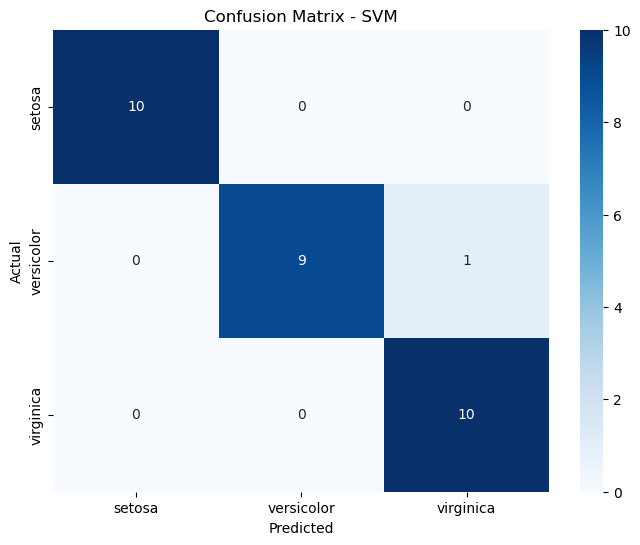

In [141]:
# Get best model
best_svm = grid_search_svm.best_estimator_

# Predict on test set
y_pred_svm = grid_search_svm.predict(X_test_scaled)

# Calculate accuracy
print(f'Test accuracy: {accuracy_score(y_test, y_pred_svm):.4f}')
print()

# Detailed classification report
print(f'Calssification Report:\n {classification_report(y_test, y_pred_svm, target_names=iris.target_names)}')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize = (8, 6))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', xticklabels = iris.target_names, yticklabels = iris.target_names)

plt.title('Confusion Matrix - SVM')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### Visualize GridSearchCV Results

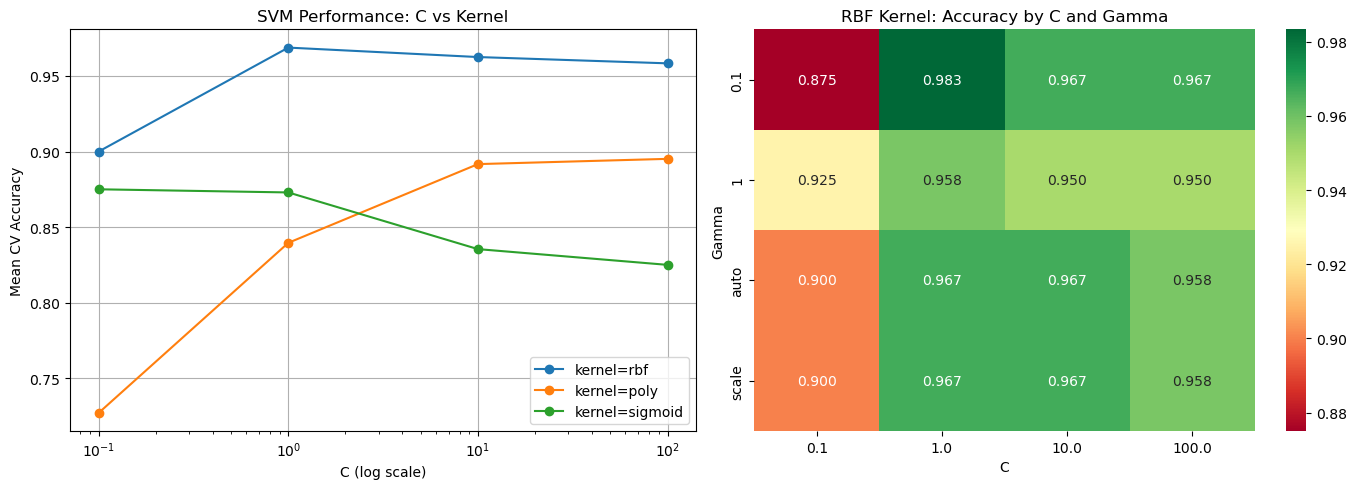

In [142]:
# Convert results to DataFrame
results_df = pd.DataFrame(grid_search_svm.cv_results_)

# Plot mean test scores for top parameters
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot C vs accuracy for different kernels
for kernel in ['rbf', 'poly', 'sigmoid']:
    subset = results_df[results_df['param_kernel'] == kernel]
    if not subset.empty:
        # Group by 'param_C', average the scores, and sort the C values correctly
        grouped = subset.groupby('param_C')['mean_test_score'].mean().sort_index()
        
        # Extract the numeric C values (index) and their respective scores (values)
        c_values = grouped.index.astype(float)
        mean_scores = grouped.values
        
        axes[0].plot(c_values, mean_scores, marker='o', label=f'kernel={kernel}')

axes[0].set_xscale('log')
axes[0].set_xlabel('C (log scale)')
axes[0].set_ylabel('Mean CV Accuracy')
axes[0].set_title('SVM Performance: C vs Kernel')
axes[0].legend()
axes[0].grid(True)


# Plot parameter heatmap for rbf kernel
rbf_results = results_df[results_df['param_kernel'] == 'rbf']
rbf_pivot = rbf_results.pivot_table(
    values='mean_test_score',
    index='param_gamma',
    columns='param_C',
    aggfunc='mean'
)

sns.heatmap(rbf_pivot, annot=True, fmt='.3f', cmap='RdYlGn', ax=axes[1])
axes[1].set_title('RBF Kernel: Accuracy by C and Gamma')
axes[1].set_xlabel('C')
axes[1].set_ylabel('Gamma')

plt.tight_layout()
plt.show()

### Complete Pipeline with GridSearchCV

In [143]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline(steps = [
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42))

])

# Parameter grid for pipeline
param_grid_pipeline = {
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['rbf', 'poly'],
    'svm__gamma': ['scale', 'auto']
}

# Grid search with pipeline
grid_search_pipe = GridSearchCV(
    pipeline,
    param_grid_pipeline,
    cv = 5,
    scoring = 'accuracy',
    n_jobs = - 1, 
    verbose = 1
)

# Fit on original X_train
grid_search_pipe.fit(X_train, y_train)

# Evaluate 
print(f'Pipeline test accuracy: {accuracy_score(y_test, grid_search_pipe.predict(X_test)):.4f}')

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Pipeline test accuracy: 0.9667


In [144]:
df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [145]:
df.shape

(891, 12)

In [146]:
df.drop(columns = ['PassengerId', 'Name', 'Ticket', 'Cabin'], inplace = True)

In [147]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')

In [148]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [149]:
df.isnull().mean()

Survived    0.000000
Pclass      0.000000
Sex         0.000000
Age         0.198653
SibSp       0.000000
Parch       0.000000
Fare        0.000000
Embarked    0.002245
dtype: float64

In [150]:
df.shape

(891, 8)

In [151]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [152]:
X = df.drop(columns = ['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [153]:
X_train.shape, X_test.shape

((712, 7), (179, 7))

In [202]:
# Feature imputation and scaling
numerical_features = ['Age', 'Fare']
categorical_features = ['Embarked', 'Sex']

numerical_pipe = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

categorical_pipe = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown = 'ignore'))
])

In [203]:
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer(transformers = [
    ('num', numerical_pipe, numerical_features),
    ('cat', categorical_pipe, categorical_features)
], remainder = 'passthrough')

In [204]:
from sklearn.linear_model import LogisticRegression
model = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

In [161]:
model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Embarked', 'Sex'])])),
                ('classifier', LogisticRegression())])

In [162]:
# Apply grid search 
param_grid = {
    'preprocessor__num__imputer__strategy': ['mean', 'median'],
    'preprocessor__cat__imputer__strategy': ['most_frequent', 'constant'],
    'classifier__C': [0.1, 1, 10, 100]
}

In [164]:
grid_search_lg = GridSearchCV(
    model,
    param_grid,
    cv = 10,
    n_jobs = -1,
    verbose = 1
)

grid_search_lg.fit(X_train, y_train)

Fitting 10 folds for each of 16 candidates, totalling 160 fits


GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'Fare']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('ohe',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Embarked',
                                                                          'Sex'])])),
                                       ('classifier', LogisticRegression())]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.1, 1, 10, 100],
                         'preprocessor__cat__imputer__strategy': ['most_frequent',
                                                                  'constant'],
                         'preprocessor__num__imputer__strategy': ['mean',
                                                                  'median']},
             verbose=1)

In [173]:
print(f'Best parameters: {grid_search_lg.best_params_}')
print()
print(f'Best cross-validation score: {grid_search_lg.best_score_:.4f}')

Best parameters: {'classifier__C': 0.1, 'preprocessor__cat__imputer__strategy': 'most_frequent', 'preprocessor__num__imputer__strategy': 'median'}

Best cross-validation score: 0.7992


In [180]:
results_df = pd.DataFrame(grid_search_lg.cv_results_)
resutls_df = results_df.sort_values('mean_test_score', ascending = False)
results_df[['param_classifier__C', 'param_preprocessor__cat__imputer__strategy', 'param_preprocessor__num__imputer__strategy', 'mean_test_score']]

,param_classifier__C,param_preprocessor__cat__imputer__strategy,param_preprocessor__num__imputer__strategy,mean_test_score
0,0.1,most_frequent,mean,0.797750
1,0.1,most_frequent,median,0.799159
2,0.1,constant,mean,0.799159
3,0.1,constant,median,0.799159
4,1.0,most_frequent,mean,0.797790
5,1.0,most_frequent,median,0.794973
6,1.0,constant,mean,0.797790
7,1.0,constant,median,0.797770
8,10.0,most_frequent,mean,0.796381
9,10.0,most_frequent,median,0.794973


In [182]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Embarked', 'Sex'])])),
                ('classifier', LogisticRegression())])

In [206]:
# Best Estimator
best_model = grid_search_lg.best_estimator_

prediction = best_model.predict(X_test)
test_score = best_model.score(X_test, y_test)
test_score

0.7932960893854749